In [1]:
import numpy as np
from matplotlib import pyplot as plt
import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord, AltAz, ICRS, EarthLocation, Angle, FK5
%matplotlib inline

# Calculating the rates of change

In [5]:
def Rates_of_Change(obs):
    delta_t = 600.0
    rubin = EarthLocation.from_geodetic(lon=-70.747698*u.deg,
                                       lat=-30.244728*u.deg,
                                       height=2663.0*u.m)
    utcoffset = -3*u.hour  # Chile time
    dt = TimeDelta(delta_t, format='sec')
    time = Time(obs[1], location=rubin) - utcoffset
    radec = SkyCoord.from_name(obs[0])
    altaz = radec.transform_to(AltAz(obstime=time,location=rubin))
    alt = altaz.alt.value
    az = altaz.az.value
    new_altaz = radec.transform_to(AltAz(obstime=time+dt,location=rubin))
    new_alt = new_altaz.alt.value
    new_az = new_altaz.az.value
    alt_dot = (new_alt - alt) / delta_t
    az_dot = (new_az - az) / delta_t
    print(az, new_az, az_dot) 
    return (alt_dot, az_dot)
                     

In [3]:
obs_list = [['HD61597', '2021-1-21 22:30', True],
           ['HD185975', '2021-1-21 22:53', True],
           ['HD49798', '2021-1-21 23:35', True],
           ['HD74000', '2021-1-21 23:51', True],
           ['HD185975', '2021-1-22 00:13', True],
           ['HD49798', '2021-1-22 00:21', False],
           ['HD74000', '2021-1-22 00:27', True],
           ['HD185975', '2021-1-22 00:37', True],
           ['HD49798', '2021-1-22 00:45', False],
           ['HD85552', '2021-1-22 00:51', True],
           ['HD74000', '2021-1-22 00:58', True],
           ['HD185975', '2021-1-22 01:09', True],
           ['HD85552', '2021-1-22 01:16', True],
           ['HD74000', '2021-1-22 01:46', False],
           ['HD185975', '2021-1-22 01:50', True],
           ['HD49798', '2021-1-22 01:58', False],
           ['HD85552', '2021-1-22 02:15', True],
           ['HD185975', '2021-1-22 02:26', True],
           ['HD49798', '2021-1-22 02:34', True],
           ['HD85552', '2021-1-22 02:38', True],
           ['HD74000', '2021-1-22 02:46', False],
           ['HD185975', '2021-1-22 02:51', True],
           ['HD49798', '2021-1-22 03:05', True],
           ['HD85552', '2021-1-22 03:12', False],
           ['HD74000', '2021-1-22 03:18', True],
           ['HD185975', '2021-1-22 03:29', True],
           ['HD61597', '2021-1-21 22:30', True]]

In [9]:
Rates_of_Change(obs_list[3])

76.0363540660512 73.98034645598645 -0.0034266793501079224


(0.0034865549204665196, -0.0034266793501079224)

136.99781609892247 137.91455365923787 0.0015278959338589952
182.26921733851282 182.18230552898976 -0.000144853015871765
148.42860649067833 153.4857232263093 0.00842852789271826
76.0363540660512 73.98034645598645 -0.0034266793501079224
181.47308825219073 181.35963409845988 -0.00018909025621809404
177.12528617422464 184.4708110176562 0.012242541405719247
67.67857218672695 64.76487778347214 -0.0048561573387580145
181.19675780074303 181.07781827152405 -0.00019823254869829536
194.37541461196986 200.8356300326354 0.010767025701109247
114.75446014378296 114.93118060740136 0.00029453410603065794
57.367497215220816 53.04767358682958 -0.007199706047318723
180.80968761763643 180.68536205679402 -0.00020720926807067978
115.44708779962666 115.99785553434508 0.0009179462245306998
29.509236218904842 21.01001255010676 -0.014165372781330135
180.2931996481888 180.16530252638626 -0.00021316186967088887
226.05676295007652 228.11245695817388 0.0034261566801622695
122.91858033538394 125.85987980912559 0.0049

Text(0, 0.5, 'Rate of change of azimuth (Deg/sec)')

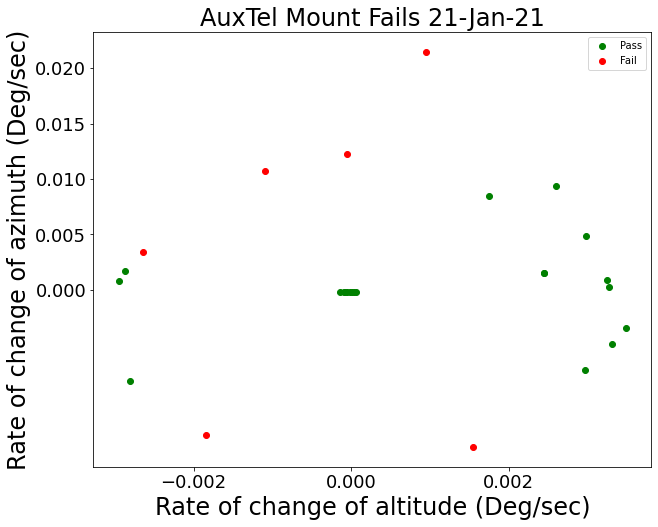

In [6]:
pass_x = []
pass_y = []
fail_x = []
fail_y = []
for obs in obs_list:
    (alt_dot, az_dot) = Rates_of_Change(obs)
    #print(obs[0], az_dot, obs[1], obs[2])
    if obs[2]:
        pass_x.append(alt_dot)
        pass_y.append(az_dot)
    else:
        fail_x.append(alt_dot)
        fail_y.append(az_dot)
fig = plt.figure(figsize = (10,8))
plt.scatter(pass_x, pass_y, color='green', label = 'Pass')
plt.scatter(fail_x, fail_y, color='red', label = 'Fail')
plt.legend()
plt.title("AuxTel Mount Fails 21-Jan-21", fontsize = 24)
plt.xlabel("Rate of change of altitude (Deg/sec)", fontsize = 24)
plt.xticks([ -0.002, 0.0, 0.002], fontsize=18)
plt.yticks([0.0, 0.005, 0.01, 0.015, 0.02], fontsize=18)
plt.ylabel("Rate of change of azimuth (Deg/sec)", fontsize=24)
#plt.savefig("/home/craiglagegit/DATA/Mount_Fails_21Jan21.png")